# Problem Understanding, Dataset & EDA
**Project identifier:** Gima  ·  **Course:** IT3051 Fundamentals of Data Mining – Mini Project 2026  ·  **Stage 5 – Progress Evaluation 1**

> **Main explanation (say this first in the viva):** The project uses historical building-violation records to predict violation severity using supervised machine learning.

**Viva rule — for every step be ready to say:** ① *What* was done · ② *Why* it was done · ③ *How* it was implemented.

> **About the outputs in this notebook.** Cells copied unchanged from the team's original notebooks keep the outputs from the original run on the real data.
> Cells that were newly written or reorganised for the viva have **no saved output** — run the notebook top-to-bottom (Kernel → Restart & Run All) before the evaluation so every number on screen is one you can explain.

## 1. Problem scenario (Stage 1)

| Item | BuildSafe-AI |
|---|---|
| **Real-world problem** | The NYC Department of Buildings (DOB) issues ECB violations when buildings break safety or construction rules. Some are *immediately hazardous*, others are minor. Reviewers need to know how serious a violation is **as soon as it is issued**, so scarce inspection effort goes to the dangerous ones first. |
| **Prediction objective** | Predict the severity class of a violation from the information available when it is issued. |
| **Target variable** | `SEVERITY` — `CLASS - 1` (immediately hazardous), `CLASS - 2` (major), `CLASS - 3` (lesser) |
| **Data-mining task** | **Multi-class classification** (3 classes; supervised learning — the correct answer is known for every historical record) |
| **Users / stakeholders** | e.g. building-safety and inspection planners, property owners / managers, compliance and insurance teams |
| **Decisions supported** | Which violations to prioritise for follow-up, where to allocate inspection resources, which buildings look high-risk |
| **System inputs** | Violation type, borough, infraction code and legal section, respondent city / ZIP, issue date, the building's earlier violation history, the violation description text |
| **System output** | Predicted severity class for the new violation |
| **Prediction point** | **Issue time.** Anything that only exists *after* issue (hearing, payment, status changes) cannot be used → this is the root of the data-leakage work in Notebooks 3 and 4. |

## 2. Dataset selection and justification (Stage 2)

| Proposal field | Answer |
|---|---|
| **Dataset name / source** | *DOB ECB Violations* — NYC Department of Buildings, published on the NYC Open Data portal |
| **URL and citation** | ✏️ *Paste the exact NYC Open Data URL, dataset owner and access date here (the file on disk is named `DOB_ECB_Violations_20260913 (1).csv`, i.e. exported 13 Sep 2026).* |
| **Real-world context** | Official city records of building-safety violations |
| **Size** | 102,467 records × 46 columns (one row = one ECB violation) |
| **Target** | `SEVERITY` (3 classes) |
| **Task** | Multi-class classification |
| **Why it fits the scenario** | It contains the exact quantity we want to predict (severity) plus information known at issue time (type, location, infraction code, date, description, building identifier) and a building identifier that allows a per-building history. It was chosen because it matches the scenario, not because it is easy to load. |
| **Data-quality observations** | 14 columns are 100 % empty; several others are >97 % empty; dates are stored as `YYYYMMDD` integers; money is stored as text with commas; free-text fields are inconsistent (see Notebook 2). |
| **Ethical / privacy / licensing** | Public open data. It contains respondent (owner/company) names and addresses, so those high-cardinality identifying columns are **not used as features**. Results are decision *support*, not automatic penalties. |
| **Instructor validation** | ✏️ *Add the date and evidence of approval.* |

## 3. Load the dataset and inspect its structure

**What:** load the CSV into a pandas DataFrame and check size, columns and types.
**Why:** before any preprocessing we must know what one row represents and what each column contains.
**How:** `pd.read_csv()` → `df.shape` → `df.head()` → `df.columns` → `df.info()`.

In [1]:
import pandas as pd

file_path = "../data/raw/DOB_ECB_Violations_20260913 (1).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


C:\Users\wenur\AppData\Local\Temp\ipykernel_17972\3939217174.py:5: DtypeWarning: Columns (0: SECTION_LAW_DESCRIPTION3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 102467
Columns: 46


In [3]:
df.head()

,ISN_DOB_BIS_EXTRACT,ECB_VIOLATION_NUMBER,ECB_VIOLATION_STATUS,DOB_VIOLATION_NUMBER,BIN,BORO,BLOCK,LOT,HEARING_DATE,HEARING_TIME,...,SECTION_LAW_DESCRIPTION7,INFRACTION_CODE8,SECTION_LAW_DESCRIPTION8,INFRACTION_CODE9,SECTION_LAW_DESCRIPTION9,INFRACTION_CODE10,SECTION_LAW_DESCRIPTION10,AGGRAVATED_LEVEL,HEARING_STATUS,CERTIFICATION_STATUS
0,1749575,39190613X,RESOLVE,NaN,2026562.0,2,3813.0,19.0,20260821,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
1,1729620,39156049P,ACTIVE,NaN,1003388.0,1,279.0,69.0,20270415,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
2,1801198,39193627K,ACTIVE,NaN,5020516.0,5,795.0,41.0,20260902,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DEFAULT,NO COMPLIANCE RECORDED
3,1793922,39169086R,ACTIVE,NaN,4139680.0,4,6381.0,54.0,20260908,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
4,1741922,35730749Y,ACTIVE,07222026SR07NS01,2016355.0,2,3277.0,2.0,20261030,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN


In [4]:
print(df.columns.tolist())

['ISN_DOB_BIS_EXTRACT', 'ECB_VIOLATION_NUMBER', 'ECB_VIOLATION_STATUS', 'DOB_VIOLATION_NUMBER', 'BIN', 'BORO', 'BLOCK', 'LOT', 'HEARING_DATE', 'HEARING_TIME', 'SERVED_DATE', 'ISSUE_DATE', 'SEVERITY', 'VIOLATION_TYPE', 'RESPONDENT_NAME', 'RESPONDENT_HOUSE_NUMBER', 'RESPONDENT_STREET', 'RESPONDENT_CITY', 'RESPONDENT_ZIP', 'VIOLATION_DESCRIPTION', 'PENALITY_IMPOSED', 'AMOUNT_PAID', 'BALANCE_DUE', 'INFRACTION_CODE1', 'SECTION_LAW_DESCRIPTION1', 'INFRACTION_CODE2', 'SECTION_LAW_DESCRIPTION2', 'INFRACTION_CODE3', 'SECTION_LAW_DESCRIPTION3', 'INFRACTION_CODE4', 'SECTION_LAW_DESCRIPTION4', 'INFRACTION_CODE5', 'SECTION_LAW_DESCRIPTION5', 'INFRACTION_CODE6', 'SECTION_LAW_DESCRIPTION6', 'INFRACTION_CODE7', 'SECTION_LAW_DESCRIPTION7', 'INFRACTION_CODE8', 'SECTION_LAW_DESCRIPTION8', 'INFRACTION_CODE9', 'SECTION_LAW_DESCRIPTION9', 'INFRACTION_CODE10', 'SECTION_LAW_DESCRIPTION10', 'AGGRAVATED_LEVEL', 'HEARING_STATUS', 'CERTIFICATION_STATUS']


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 102467 entries, 0 to 102466
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ISN_DOB_BIS_EXTRACT        102467 non-null  int64  
 1   ECB_VIOLATION_NUMBER       102467 non-null  str    
 2   ECB_VIOLATION_STATUS       102467 non-null  str    
 3   DOB_VIOLATION_NUMBER       21654 non-null   str    
 4   BIN                        102372 non-null  float64
 5   BORO                       102467 non-null  int64  
 6   BLOCK                      101980 non-null  float64
 7   LOT                        101980 non-null  float64
 8   HEARING_DATE               102467 non-null  int64  
 9   HEARING_TIME               102467 non-null  int64  
 10  SERVED_DATE                102467 non-null  int64  
 11  ISSUE_DATE                 102467 non-null  int64  
 12  SEVERITY                   102467 non-null  str    
 13  VIOLATION_TYPE             102467 non-nu

**Observation.** Rows = 102,467, columns = 46. The `DtypeWarning` appears because `SECTION_LAW_DESCRIPTION3` is almost entirely empty and has mixed types — it is dropped later, so it does not matter.

## 4. Feature types

**What:** separate the columns into types. **Why:** each type needs different preprocessing (encoding, scaling, date conversion, text vectorisation). **How:** `select_dtypes` + `nunique()`.

| Type | Columns | Later treatment |
|---|---|---|
| Identifiers | `ISN_DOB_BIS_EXTRACT`, `ECB_VIOLATION_NUMBER`, `DOB_VIOLATION_NUMBER` | dropped (no predictive meaning) |
| Categorical | `VIOLATION_TYPE`, `BORO`, `INFRACTION_CODE1`, `RESPONDENT_CITY`, `RESPONDENT_ZIP`, … | one-hot encoding |
| Dates stored as integers | `ISSUE_DATE`, `SERVED_DATE`, `HEARING_DATE` | convert to datetime → date features |
| Money stored as text | `PENALITY_IMPOSED`, `AMOUNT_PAID`, `BALANCE_DUE` | post-issue outcomes → excluded |
| Free text | `VIOLATION_DESCRIPTION` | scrub leakage → TF-IDF |
| Building keys | `BIN`, `BLOCK`, `LOT` | `BIN` used for history features |
| Target | `SEVERITY` | separated as `y` |

In [6]:
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

print("Number of categorical columns:", len(categorical_columns))

for col in categorical_columns:
    print(f"{col}: {df[col].nunique(dropna=True)} unique values")

Number of categorical columns: 22
ECB_VIOLATION_NUMBER: 102467 unique values
ECB_VIOLATION_STATUS: 2 unique values
DOB_VIOLATION_NUMBER: 19986 unique values
SEVERITY: 3 unique values
VIOLATION_TYPE: 12 unique values
RESPONDENT_NAME: 36932 unique values
RESPONDENT_HOUSE_NUMBER: 8702 unique values
RESPONDENT_STREET: 10036 unique values
RESPONDENT_CITY: 1312 unique values
RESPONDENT_ZIP: 1411 unique values
VIOLATION_DESCRIPTION: 97978 unique values
PENALITY_IMPOSED: 98 unique values
AMOUNT_PAID: 1286 unique values
BALANCE_DUE: 380 unique values
INFRACTION_CODE1: 326 unique values
SECTION_LAW_DESCRIPTION1: 225 unique values
INFRACTION_CODE2: 128 unique values
SECTION_LAW_DESCRIPTION2: 89 unique values
SECTION_LAW_DESCRIPTION3: 2 unique values
AGGRAVATED_LEVEL: 3 unique values
HEARING_STATUS: 8 unique values
CERTIFICATION_STATUS: 5 unique values


In [7]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ISN_DOB_BIS_EXTRACT,102467.0,1.565285e+06,3.710298e+05,81.0,1.435650e+06,1736202.0,1.806802e+06,1847514.0
BIN,102372.0,2.901839e+06,1.206617e+06,1000000.0,2.012957e+06,3089176.0,4.032027e+06,5871468.0
BORO,102467.0,2.762128e+00,1.136447e+00,1.0,2.000000e+00,3.0,4.000000e+00,5.0
BLOCK,101980.0,3.900134e+03,3.253183e+03,1.0,1.475000e+03,2999.0,5.399000e+03,20179.0
LOT,101980.0,3.363810e+02,1.442267e+03,0.0,1.300000e+01,33.0,5.900000e+01,9999.0
HEARING_DATE,102467.0,2.025916e+07,5.949054e+03,20250206.0,2.025120e+07,20260617.0,2.026102e+07,20271222.0
HEARING_TIME,102467.0,8.984060e+02,9.128378e+01,800.0,8.300000e+02,830.0,9.300000e+02,1910.0
SERVED_DATE,102467.0,2.025365e+07,1.674797e+05,0.0,2.025062e+07,20251121.0,2.026042e+07,20260910.0
ISSUE_DATE,102467.0,2.025494e+07,4.881917e+03,20250101.0,2.025060e+07,20251117.0,2.026042e+07,20260910.0
INFRACTION_CODE3,20.0,9.500001e+07,2.236064e+07,176.0,1.000000e+08,100000000.0,1.000000e+08,100000000.0


## 5. Target variable and class imbalance

**What:** count how many records fall in each severity class. **Why:** an imbalanced target changes how we split data and how we judge models. **How:** `value_counts()` (counts and percentages) and a bar chart.

In [8]:
print(df["SEVERITY"].value_counts(dropna=False))

SEVERITY
CLASS - 2    57607
CLASS - 1    40673
CLASS - 3     4187
Name: count, dtype: int64


In [9]:
print(df["SEVERITY"].value_counts(normalize=True, dropna=False) * 100)

SEVERITY
CLASS - 2    56.220051
CLASS - 1    39.693755
CLASS - 3     4.086194
Name: proportion, dtype: float64


In [10]:
print(df["SEVERITY"].unique())

<StringArray>
['CLASS - 2', 'CLASS - 1', 'CLASS - 3']
Length: 3, dtype: str


In [11]:
import matplotlib.pyplot as plt
print("Matplotlib works!")

Matplotlib works!


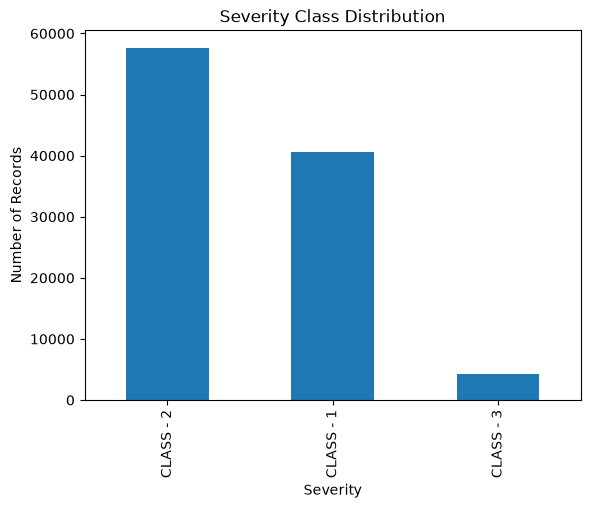

In [12]:
df["SEVERITY"].value_counts().plot(
    kind="bar",
    title="Severity Class Distribution"
)

plt.xlabel("Severity")
plt.ylabel("Number of Records")
plt.show()

**Observation — class imbalance.** `CLASS - 2` ≈ 56.2 %, `CLASS - 1` ≈ 39.7 %, `CLASS - 3` ≈ 4.1 %.
**Consequences:** (1) plain accuracy is misleading — a model that ignores Class 3 still scores ~96 % on it, so we report **macro-F1 and per-class recall**; (2) class weights ("balanced") are used when training; (3) the rare class needs to appear in both training and test data (checked in Notebook 4).

## 6. Missing values and duplicates (overview — Member 2 goes deeper)

In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

INFRACTION_CODE7             102467
SECTION_LAW_DESCRIPTION10    102467
INFRACTION_CODE10            102467
SECTION_LAW_DESCRIPTION9     102467
INFRACTION_CODE9             102467
SECTION_LAW_DESCRIPTION8     102467
INFRACTION_CODE8             102467
SECTION_LAW_DESCRIPTION7     102467
INFRACTION_CODE5             102467
SECTION_LAW_DESCRIPTION6     102467
INFRACTION_CODE6             102467
SECTION_LAW_DESCRIPTION5     102467
INFRACTION_CODE4             102467
SECTION_LAW_DESCRIPTION4     102467
INFRACTION_CODE3             102447
SECTION_LAW_DESCRIPTION3     102447
SECTION_LAW_DESCRIPTION2     100342
INFRACTION_CODE2              99864
DOB_VIOLATION_NUMBER          80813
CERTIFICATION_STATUS          31821
RESPONDENT_HOUSE_NUMBER       22754
RESPONDENT_ZIP                 8932
HEARING_STATUS                 8804
RESPONDENT_CITY                8279
SECTION_LAW_DESCRIPTION1       7994
RESPONDENT_STREET              7784
LOT                             487
BLOCK                       

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (df.isnull().mean() * 100).values,
    "Unique_Values": df.nunique(dropna=True).values
})

summary

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,ISN_DOB_BIS_EXTRACT,int64,0,0.000000,102467
1,ECB_VIOLATION_NUMBER,str,0,0.000000,102467
2,ECB_VIOLATION_STATUS,str,0,0.000000,2
3,DOB_VIOLATION_NUMBER,str,80813,78.867343,19986
4,BIN,float64,95,0.092713,38743
5,BORO,int64,0,0.000000,5
6,BLOCK,float64,487,0.475275,9887
7,LOT,float64,487,0.475275,643
8,HEARING_DATE,int64,0,0.000000,568
9,HEARING_TIME,int64,0,0.000000,39


In [16]:
summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
30,SECTION_LAW_DESCRIPTION4,float64,102467,100.000000,0
33,INFRACTION_CODE6,float64,102467,100.000000,0
34,SECTION_LAW_DESCRIPTION6,float64,102467,100.000000,0
31,INFRACTION_CODE5,float64,102467,100.000000,0
32,SECTION_LAW_DESCRIPTION5,float64,102467,100.000000,0
37,INFRACTION_CODE8,float64,102467,100.000000,0
38,SECTION_LAW_DESCRIPTION8,float64,102467,100.000000,0
39,INFRACTION_CODE9,float64,102467,100.000000,0
40,SECTION_LAW_DESCRIPTION9,float64,102467,100.000000,0
41,INFRACTION_CODE10,float64,102467,100.000000,0


**Observation.** 14 columns are completely empty (`INFRACTION_CODE4–10`, `SECTION_LAW_DESCRIPTION4–10`); `INFRACTION_CODE3` / `SECTION_LAW_DESCRIPTION3` are 99.98 % empty and `INFRACTION_CODE2` is 97.5 % empty. The raw file has **no exact duplicate rows** and every `ECB_VIOLATION_NUMBER` is unique.

## 7. Date columns

**What:** look at the range of the three date fields. **Why:** dates decide the *order of events* — and therefore which columns are legitimately known at prediction time. **How:** min / max / most common values.

In [17]:
date_columns = [
    "HEARING_DATE",
    "SERVED_DATE",
    "ISSUE_DATE"
]

for col in date_columns:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


HEARING_DATE
Min: 20250206
Max: 20271222

SERVED_DATE
Min: 0
Max: 20260910

ISSUE_DATE
Min: 20250101
Max: 20260910


In [18]:
date_columns = [
    "HEARING_DATE",
    "SERVED_DATE",
    "ISSUE_DATE"
]

for col in date_columns:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


HEARING_DATE
HEARING_DATE
20261007    815
20261016    756
20261110    755
20261014    658
20261002    648
20260807    643
20261030    617
20260715    616
20261104    615
20261028    593
Name: count, dtype: int64

SERVED_DATE
SERVED_DATE
20260604    396
20250424    375
20260507    371
20260521    371
20250807    370
20250501    370
20250717    368
20260601    367
20260512    365
20250731    362
Name: count, dtype: int64

ISSUE_DATE
ISSUE_DATE
20250408    985
20250225    956
20250701    861
20260420    726
20250129    565
20250211    453
20250528    424
20250108    404
20260302    350
20260730    343
Name: count, dtype: int64


**Observation.** Violations were issued between 2025-01-01 and 2026-09-10 (~20 months). `HEARING_DATE` runs as far as 2027 — hearings are scheduled *after* issue, so hearing information is **not available at prediction time**. `SERVED_DATE` contains `0` placeholders (7 rows).

## 8. Important columns and relationships with the target

In [19]:
important_columns = [
    "ECB_VIOLATION_STATUS",
    "VIOLATION_TYPE",
    "SEVERITY",
    "AGGRAVATED_LEVEL",
    "HEARING_STATUS",
    "CERTIFICATION_STATUS"
]

for col in important_columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts(dropna=False))


ECB_VIOLATION_STATUS
ECB_VIOLATION_STATUS
ACTIVE     59031
RESOLVE    43436
Name: count, dtype: int64

VIOLATION_TYPE
VIOLATION_TYPE
Construction           74655
Unknown                13585
Elevators               6999
Boilers                 2275
Zoning                  1385
Local Law               1241
Quality of Life          917
Site Safety              580
Cranes and Derricks      355
Plumbing                 280
Signs                    178
Public Assembly           17
Name: count, dtype: int64

SEVERITY
SEVERITY
CLASS - 2    57607
CLASS - 1    40673
CLASS - 3     4187
Name: count, dtype: int64

AGGRAVATED_LEVEL
AGGRAVATED_LEVEL
NO                            94199
AGGRAVATED OFFENSE LEVEL 1     7323
AGGRAVATED OFFENSE LEVEL 2      945
Name: count, dtype: int64

HEARING_STATUS
HEARING_STATUS
DEFAULT               23087
IN VIOLATION          21061
PENDING               20952
NaN                    8804
POP/IN-VIO             8266
CURED/IN-VIO           6675
DISMISSED             

In [20]:
# Share of each severity class inside every violation type (row-normalised, %)
pd.crosstab(df["VIOLATION_TYPE"], df["SEVERITY"], normalize="index").mul(100).round(1)

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
VIOLATION_TYPE,,,
Boilers,4.4,84.4,11.2
Construction,39.6,56.5,3.9
Cranes and Derricks,32.1,67.9,0.0
Elevators,52.4,47.6,0.0
Local Law,0.0,100.0,0.0
Plumbing,38.2,57.1,4.6
Public Assembly,100.0,0.0,0.0
Quality of Life,82.2,17.8,0.0
Signs,59.6,40.4,0.0


In [21]:
pd.crosstab(
    df["AGGRAVATED_LEVEL"],
    df["SEVERITY"],
    margins=True
)

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3,All
AGGRAVATED_LEVEL,,,,
AGGRAVATED OFFENSE LEVEL 1,3066,4206,51,7323
AGGRAVATED OFFENSE LEVEL 2,777,165,3,945
NO,36830,53236,4133,94199
All,40673,57607,4187,102467


In [22]:
pd.crosstab(
    df["AGGRAVATED_LEVEL"],
    df["SEVERITY"],
    normalize="index"
).round(3) * 100

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
AGGRAVATED_LEVEL,,,
AGGRAVATED OFFENSE LEVEL 1,41.9,57.4,0.7
AGGRAVATED OFFENSE LEVEL 2,82.2,17.5,0.3
NO,39.1,56.5,4.4


**Observations.**
- `Construction` is the dominant violation type (74,655 rows ≈ 73 %); `Unknown` is a genuine category with 13,585 rows.
- The mix of severity classes differs by violation type, so `VIOLATION_TYPE` carries predictive signal.
- `AGGRAVATED_LEVEL` is strongly related to severity (Level 2 is 82 % Class 1) **but** we cannot prove when it is assigned — it may be set after issue. It is therefore excluded (reasoning in Notebooks 2 and 4).

### Repeated buildings → history is possible

In [23]:
bin_counts = df["BIN"].value_counts()

print("Total unique BINs:", bin_counts.shape[0])

print("\nBuildings with only 1 violation:")
print((bin_counts == 1).sum())

print("\nBuildings with more than 1 violation:")
print((bin_counts > 1).sum())

print("\nBuildings with 5+ violations:")
print((bin_counts >= 5).sum())

print("\nBuildings with 10+ violations:")
print((bin_counts >= 10).sum())

print("\nMaximum violations for one building:")
print(bin_counts.max())

Total unique BINs: 38743

Buildings with only 1 violation:
18826

Buildings with more than 1 violation:
19917

Buildings with 5+ violations:
5603

Buildings with 10+ violations:
1332

Maximum violations for one building:
61


**Observation.** 38,743 distinct buildings (`BIN`); 19,917 of them have more than one violation and the busiest has 61. Because buildings repeat, *earlier* violations of the same building can be used as features (Notebook 3) — as long as only **earlier** dates are counted.

## 9. EDA findings → decisions

| # | Finding (evidence) | Decision / implication |
|---|---|---|
| 1 | 102,467 × 46; each `ECB_VIOLATION_NUMBER` unique | one row = one violation; identifiers carry no signal → drop |
| 2 | 14 columns 100 % empty, several >97 % empty | drop sparse infraction / law-description columns 2–10 |
| 3 | Severity is imbalanced (56 / 40 / 4 %) | macro-F1, per-class recall, class weights, temporal split that keeps Class 3 in both sets |
| 4 | Dates are `YYYYMMDD` integers; `SERVED_DATE` has `0` placeholders | convert to datetime, treat `0` as missing |
| 5 | Hearing / payment / status columns exist after issue | exclude as **post-issue leakage** |
| 6 | Money columns are text; some balances are negative | would need conversion — but excluded as outcomes anyway |
| 7 | `VIOLATION_DESCRIPTION` is free text (97,978 unique values) and often quotes "CLASS 1/2" | scrub severity mentions, then TF-IDF |
| 8 | Buildings repeat (max 61 violations) | leakage-safe building-history features |
| 9 | Data covers only ~20 months | use a **time-based** split; note limited seasonality |

**Handed to Member 2** → cleaning. **Handed to Member 4** → leakage-safe splitting.

## 10. Viva preparation — Member 1

**Q1. What problem does BuildSafe-AI solve?** It predicts how severe a new NYC building violation is at the time it is issued, so inspection and follow-up effort can be prioritised.

**Q2. Why is this a classification problem?** The target `SEVERITY` has three discrete classes, and we learn from labelled historical records → supervised multi-class classification.

**Q3. Why this dataset, and how was it validated?** It is public, credible (NYC DOB), large enough (102k rows), has a clear target, and has features available at issue time. It was submitted as a dataset proposal and approved by the instructor before analysis began.

**Q4. What does the target mean?** Class 1 = immediately hazardous, Class 2 = major, Class 3 = lesser.

**Q5. What is the class imbalance and why does it matter?** ~56 / 40 / 4 %. Accuracy alone hides poor performance on the rare Class 3, so we use macro-F1, per-class recall and class weights.

**Q6. Which EDA finding influenced the later steps most?** Three: post-issue columns (→ leakage exclusion), repeated buildings (→ history features) and the date range (→ temporal split).

**Q7. Limitations of the dataset?** Only ~20 months of data, so seasonality cannot be separated from trend; building history is truncated at the start of the window; text fields are inconsistent; the label is closely tied to the infraction code (discussed in Notebook 4).

**Q8. What was the prediction point?** Issue time. Only information available then may be used.